In [4]:
import matplotlib.pyplot as plt
import numpy as np

import geopandas as gpd
import pandas as pd

gdf = gpd.read_file('Berney_merge_legende_v7-7.geojson').set_crs('EPSG:2056', allow_override=True).to_crs('EPSG:4326')
gdf = gdf.reset_index()
# fixing page number issues
gdf['page'] = pd.to_numeric(gdf['page'], errors='coerce').astype('Int64')

def remove_etc(use_l:str):
    if pd.isna(use_l):
        return use_l
    if 'etc' in use_l:
        return use_l.replace('etc', '').strip()
    if 'etc.' in use_l:
        return use_l.replace('etc.', '').strip()
    return use_l

def use_list_to_list(use_l:str):
    if pd.isna(use_l):
        return use_l
    use_items = None
    if '|' in use_l:
        use_items = [item.strip() for item in use_l.split('|')]
    elif ' et ' in use_l:
        use_items = [item.strip() for item in use_l.split(' et ')]
    else:   
        use_items = [use_l.strip()]
    final_items = []
    for itm in use_items:
        if ',' in itm:
            sub_items = [sub_item.strip() for sub_item in itm.split(',')]
            final_items.extend(sub_items)
        else:
            final_items.append(remove_etc(itm))
    return [f for f in final_items if f]
# homogenize land use entries between appelation with "|" and "et".
gdf['use'] = gdf['use'].apply(use_list_to_list)
df_wh = pd.read_csv('wh_images.csv')

def format_filename_to_code(filename:str):
    code = filename.replace('PC_1827-1831_Berney_Vol-', '')
    if 'legende' in code:
        code = code.replace('_legende', '')
    code = code.split('_')[-1].replace('.jpg', '')
    if code.isnumeric():
        code = int(code)
    return code

df_wh['code'] = df_wh['filename'].apply(format_filename_to_code)

def find_the_right_filename(code):
    matched = df_wh[df_wh['code'] == code]
    if len(matched) == 1:
        return matched.iloc[0]['filename']
    if len(matched) > 1:
        # return only the one whose has "legende" in the filename (the other one is purely a map)
        for idx, row in matched.iterrows():
            if 'legende' in row['filename']:
                return row['filename']
    return None

gdf['page_filename'] = gdf['page'].apply(find_the_right_filename)

# removes duplicates based on geometry (manually checked, they are duplicates, not different entries pointing to the same geometry)
gdf = gpd.GeoDataFrame(gdf.groupby('geometry').first().drop(columns=['index']).reset_index(), geometry='geometry')

gdf.to_file('Berney_merge_legende_v7-7_formatted_for_timeatlas.geojson', driver='GeoJSON')

In [8]:
from collections import Counter

# ── French use terms → target English categories ──────────────────────────────
# volière is intentionally excluded (deleted per request)
USE_CATEGORY_MAP = {
    # allotments
    "chenevière": "allotments",
    "jardin": "allotments",
    "jardin potager": "allotments",
    "jardin pour le chancelier": "allotments",
    "verger": "allotments",
    # animal_keeping
    "1/2 écurie": "animal_keeping",
    "1/2 grange": "animal_keeping",
    "2 écuries": "animal_keeping",
    "2 granges": "animal_keeping",
    "3 écuries": "animal_keeping",
    "basse-cour": "animal_keeping",
    "deux écuries": "animal_keeping",
    "étable": "animal_keeping",
    "étable à porcs": "animal_keeping",
    "étables à porcs": "animal_keeping",
    "écurie": "animal_keeping",
    "écuries": "animal_keeping",
    "fenil": "animal_keeping",
    "fenils": "animal_keeping",
    "grance": "animal_keeping",   # typo variant of grange
    "grange": "animal_keeping",
    "grange?": "animal_keeping",
    "granges": "animal_keeping",
    "hangar": "animal_keeping",
    "place à fumier": "animal_keeping",
    # basin
    "baignoire": "basin",
    "bains": "basin",
    "réservoir": "basin",
    # farmland
    "3/5e de champ": "farmland",
    "champ": "farmland",
    "grenier": "farmland",
    "terre": "farmland",
    # forest
    "bois": "forest",
    "bois de chênes": "forest",
    "bois de sapins": "forest",
    "bosquet": "forest",
    "buissons": "forest",
    # grass
    "2/5e de pré": "grass",
    "pré": "grass",
    "pré marais soit pâturage": "grass",
    "pâturage": "grass",
    # greenhouse_horti
    "serre": "greenhouse_horti",
    "serre sous la terrasse": "greenhouse_horti",
    # plant_nursery
    "pepinière": "plant_nursery",
    "plantage": "plant_nursery",
    # vineyard
    "pressoir": "vineyard",
    "pressoir .": "vineyard",
    "vigne": "vineyard",
    "vignes": "vineyard",
}


def harmonize_uses(use_list):
    """Map French use terms to English categories; drop volière; return sorted list or None."""
    if not isinstance(use_list, list):
        return None
    cats = set()
    for item in use_list:
        if pd.isna(item):
            continue
        s = str(item).strip()
        if s.lower() in ("volière", "voliere"):
            continue
        cat = USE_CATEGORY_MAP.get(s)
        if cat:
            cats.add(cat)
    return sorted(cats) if cats else None


gdf_agri = gdf.copy()
gdf_agri["use_harmonized"] = gdf_agri["use"].apply(harmonize_uses)

# Keep only parcels with at least one recognised category
gdf_agri = gdf_agri[gdf_agri["use_harmonized"].notna()].copy()

# use_fr = original French list; use = harmonized English categories (list)
gdf_agri = gdf_agri.rename(columns={"use": "use_fr", "use_harmonized": "use"})

print(f"Agricultural/forest features: {len(gdf_agri)}")
cat_counts = Counter(c for cats in gdf_agri["use"] for c in cats)
for cat, count in sorted(cat_counts.items()):
    print(f"  {cat}: {count}")

gdf_agri.to_file("Berney_1831_agriculture_harmonized.geojson", driver="GeoJSON")
print("Saved → Berney_1831_agriculture_harmonized.geojson")

# Compute parcel area in ares (project to metric CRS for area calculation)
gdf_agri["area_ares"] = gdf_agri.to_crs("EPSG:2056").geometry.area / 100

# Explode harmonized categories for per-category statistics
exp = (
    pd.DataFrame(gdf_agri[["use", "area_ares"]])
    .explode("use")
    .rename(columns={"use": "category"})
)
exp = exp[exp["category"].notna() & (exp["category"] != "")]

stats = (
    exp.groupby("category")
    .agg(
        n_parcels    =("area_ares", "count"),
        total_area_ha=("area_ares", lambda x: x.sum() / 100),
    )
)


Agricultural/forest features: 5650
  allotments: 1033
  animal_keeping: 667
  basin: 3
  farmland: 1297
  forest: 735
  grass: 1188
  greenhouse_horti: 43
  plant_nursery: 30
  vineyard: 674
Saved → Berney_1831_agriculture_harmonized.geojson


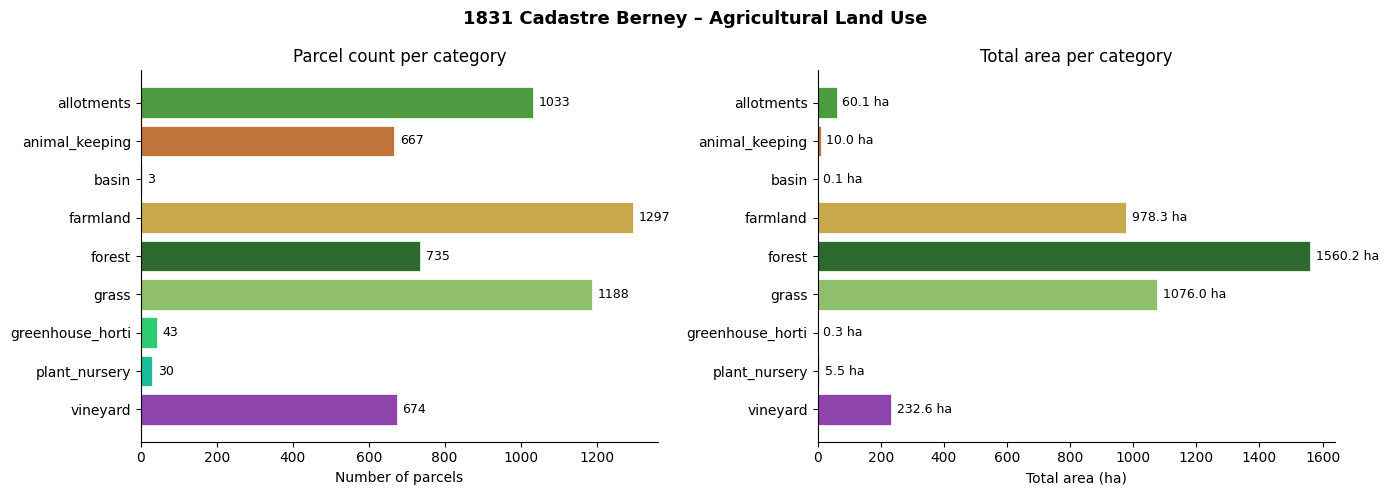

In [9]:
PALETTE = {
    "allotments":      "#4e9a41",
    "animal_keeping":  "#c0743c",
    "basin":           "#4a90d9",
    "farmland":        "#c8a84b",
    "forest":          "#2d6a2d",
    "grass":           "#8fbf6a",
    "greenhouse_horti":"#2ecc71",
    "plant_nursery":   "#1abc9c",
    "vineyard":        "#8e44ad",
}
colors = [PALETTE.get(c, "#aaaaaa") for c in stats.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("1831 Cadastre Berney – Agricultural Land Use", fontsize=13, fontweight="bold")

ax = axes[0]
bars = ax.barh(stats.index, stats["n_parcels"], color=colors, edgecolor="white", linewidth=0.5)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel("Number of parcels")
ax.set_title("Parcel count per category")
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
bars = ax.barh(stats.index, stats["total_area_ha"], color=colors, edgecolor="white", linewidth=0.5)
ax.bar_label(bars, fmt="%.1f ha", padding=4, fontsize=9)
ax.set_xlabel("Total area (ha)")
ax.set_title("Total area per category")
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("1831_agri_count_and_area.png", dpi=150, bbox_inches="tight")
plt.show()


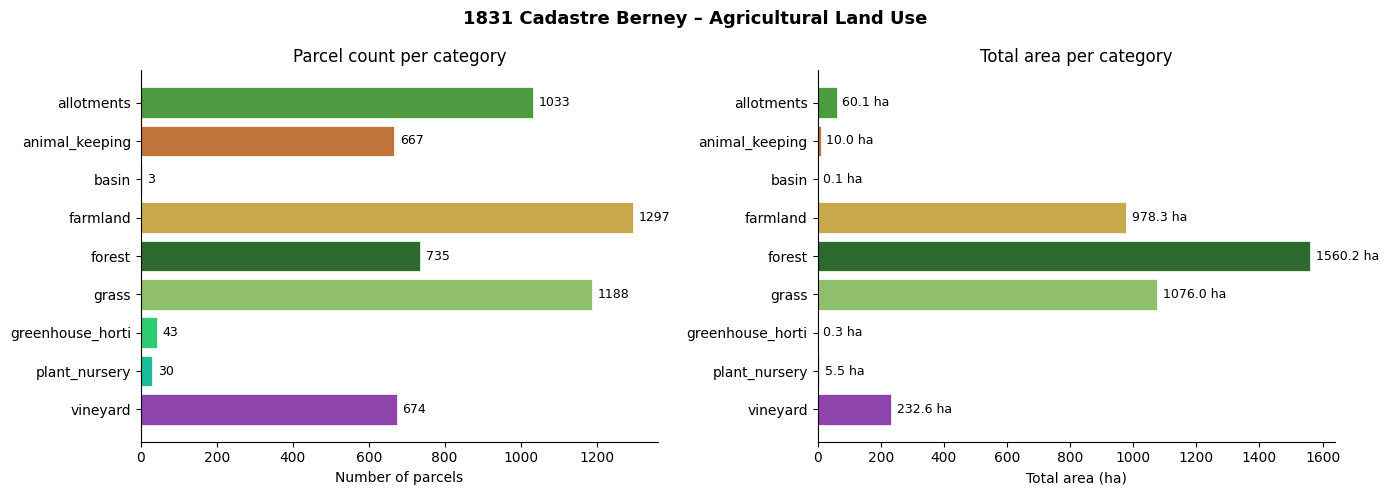

In [10]:
PALETTE = {
    "allotments":      "#4e9a41",
    "animal_keeping":  "#c0743c",
    "basin":           "#4a90d9",
    "farmland":        "#c8a84b",
    "forest":          "#2d6a2d",
    "grass":           "#8fbf6a",
    "greenhouse_horti":"#2ecc71",
    "plant_nursery":   "#1abc9c",
    "vineyard":        "#8e44ad",
}
colors = [PALETTE.get(c, "#aaaaaa") for c in stats.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("1831 Cadastre Berney – Agricultural Land Use", fontsize=13, fontweight="bold")

ax = axes[0]
bars = ax.barh(stats.index, stats["n_parcels"], color=colors, edgecolor="white", linewidth=0.5)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel("Number of parcels")
ax.set_title("Parcel count per category")
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
bars = ax.barh(stats.index, stats["total_area_ha"], color=colors, edgecolor="white", linewidth=0.5)
ax.bar_label(bars, fmt="%.1f ha", padding=4, fontsize=9)
ax.set_xlabel("Total area (ha)")
ax.set_title("Total area per category")
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("1831_agri_count_and_area.png", dpi=150, bbox_inches="tight")
plt.show()


C:\Users\mohse\AppData\Local\Temp\ipykernel_31808\79376908.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


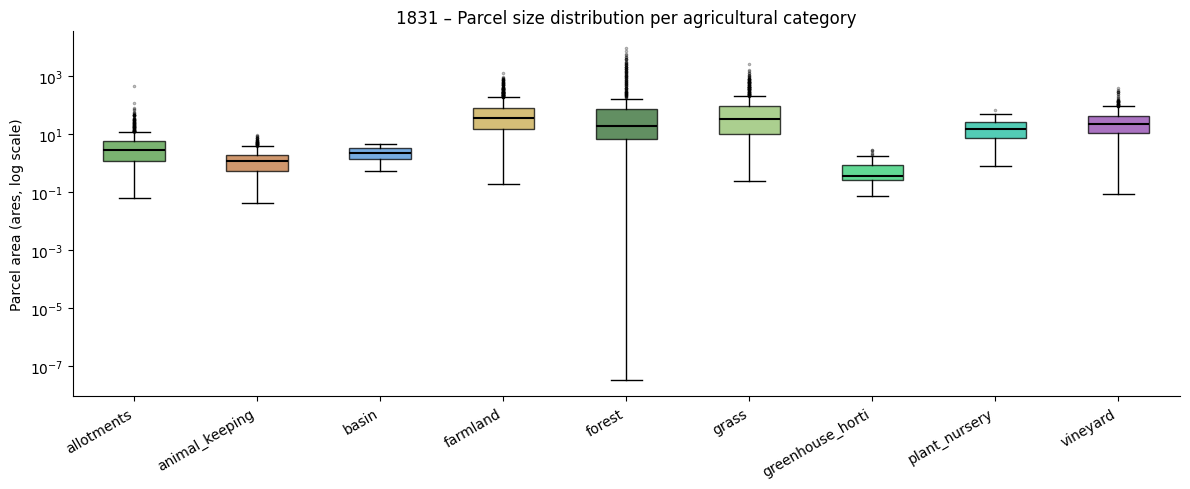

Single-category parcels:  5630  (99.6%)
Multi-category parcels :    20  (0.4%)

Top co-occurring category pairs:
  animal_keeping + vineyard: 11
  farmland + grass: 2
  animal_keeping + farmland: 2
  allotments + greenhouse_horti: 2
  allotments + farmland: 1
  greenhouse_horti + vineyard: 1
  allotments + plant_nursery: 1


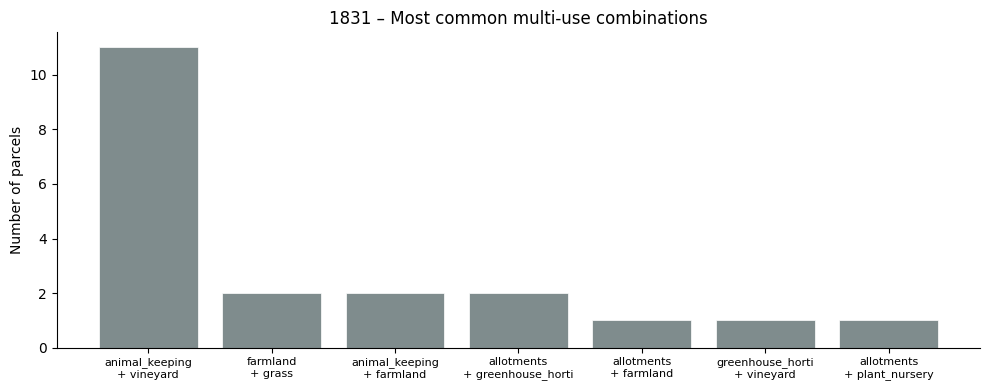

In [15]:
# ── Parcel size distribution per category (log-scale box plot) ───────────────
cat_order = stats.index.tolist()
data_by_cat = [exp[exp["category"] == cat]["area_ares"].values for cat in cat_order]
colors_ordered = [PALETTE.get(c, "#aaaaaa") for c in cat_order]

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(
    data_by_cat,
    vert=True,
    patch_artist=True,
    labels=cat_order,
    showfliers=True,
    flierprops=dict(marker=".", markersize=3, alpha=0.35, color="grey"),
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
)
for patch, color in zip(bp["boxes"], colors_ordered):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_yscale("log")
ax.set_ylabel("Parcel area (ares, log scale)")
ax.set_title("1831 – Parcel size distribution per agricultural category")
plt.xticks(rotation=30, ha="right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("1831_agri_size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Multi-use parcels ─────────────────────────────────────────────────────────
from itertools import combinations

multi = gdf_agri[gdf_agri["use"].apply(len) > 1]
print(f"Single-category parcels: {len(gdf_agri) - len(multi):>5}  ({100*(1-len(multi)/len(gdf_agri)):.1f}%)")
print(f"Multi-category parcels : {len(multi):>5}  ({100*len(multi)/len(gdf_agri):.1f}%)")

pair_counts = Counter()
for cats in multi["use"]:
    for pair in combinations(sorted(cats), 2):
        pair_counts[pair] += 1

print("\nTop co-occurring category pairs:")
top_pairs = pair_counts.most_common(10)
for (a, b), n in top_pairs:
    print(f"  {a} + {b}: {n}")

if top_pairs:
    labels = [f"{a}\n+ {b}" for (a, b), _ in top_pairs]
    counts = [n for _, n in top_pairs]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(labels, counts, color="#7f8c8d", edgecolor="white", linewidth=0.5)
    ax.set_ylabel("Number of parcels")
    ax.set_title("1831 – Most common multi-use combinations")
    ax.spines[["top", "right"]].set_visible(False)
    plt.xticks(fontsize=8)
    plt.tight_layout()
    plt.savefig("1831_agri_cooccurrence.png", dpi=150, bbox_inches="tight")
    plt.show()


In [ ]:
import os, json

PATH_1888 = "../1888-cadastre-renove/lausanne-1888-agriculture-harmonized.geojson"

if not os.path.exists(PATH_1888):
    print(f"File not found: {PATH_1888}\nRun the 1888 notebook first.")
else:
    def parse_use_col(v):
        if isinstance(v, list): return v
        if pd.isna(v): return []
        try:
            r = json.loads(v)
            return r if isinstance(r, list) else [r]
        except Exception:
            return [str(v)]

    gdf_1888 = gpd.read_file(PATH_1888).to_crs("EPSG:2056")
    gdf_1888["area_ares"] = gdf_1888.geometry.area / 100
    gdf_1888["use"] = gdf_1888["use"].apply(parse_use_col)

    exp_88 = (
        pd.DataFrame(gdf_1888[["use", "area_ares"]])
        .explode("use")
        .rename(columns={"use": "category"})
    )
    exp_88 = exp_88[exp_88["category"].notna() & (exp_88["category"] != "")]

    stats_88 = (
        exp_88.groupby("category")
        .agg(
            n_parcels    =("area_ares", "count"),
            total_area_ha=("area_ares", lambda x: x.sum() / 100),
        )
    )

    all_cats = sorted(set(stats.index) | set(stats_88.index))
    comp = pd.DataFrame({
        "1831_n":  stats   ["n_parcels"    ].reindex(all_cats, fill_value=0),
        "1888_n":  stats_88["n_parcels"    ].reindex(all_cats, fill_value=0),
        "1831_ha": stats   ["total_area_ha"].reindex(all_cats, fill_value=0),
        "1888_ha": stats_88["total_area_ha"].reindex(all_cats, fill_value=0),
    })
    comp["delta_n_pct"]  = ((comp["1888_n"]  - comp["1831_n"])  / comp["1831_n"].replace(0, float("nan")) * 100).round(1)
    comp["delta_ha_pct"] = ((comp["1888_ha"] - comp["1831_ha"]) / comp["1831_ha"].replace(0, float("nan")) * 100).round(1)

    print(f"{'Category':<20} {'1831 n':>8} {'1888 n':>8} {'Δ n%':>8} {'1831 ha':>9} {'1888 ha':>9} {'Δ ha%':>8}")
    print("-" * 75)
    for cat in all_cats:
        r = comp.loc[cat]
        print(f"{cat:<20} {int(r['1831_n']):>8} {int(r['1888_n']):>8} {r['delta_n_pct']:>7.0f}% "
              f"{r['1831_ha']:>9.1f} {r['1888_ha']:>9.1f} {r['delta_ha_pct']:>7.0f}%")

    x = np.arange(len(all_cats))
    w = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle("Agricultural Land Use: 1831 vs 1888", fontsize=13, fontweight="bold")

    for ax, (col31, col88), ylabel in [
        (axes[0], ("1831_n",  "1888_n"),  "Number of parcels"),
        (axes[1], ("1831_ha", "1888_ha"), "Total area (ha)"),
    ]:
        ax.bar(x - w/2, comp[col31], w, label="1831", color="steelblue", alpha=0.85, edgecolor="white")
        ax.bar(x + w/2, comp[col88], w, label="1888", color="coral",     alpha=0.85, edgecolor="white")
        ax.set_xticks(x)
        ax.set_xticklabels(all_cats, rotation=30, ha="right")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("1831_vs_1888_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()


Skipping field nr: unsupported OGR type: 3
Skipping field use: unsupported OGR type: 5


KeyError: 'use'